### DSC 550 - Data Mining¶
### Week 4, Exercise 4.2

In the Week 4 Exercise, you will build a linear regression model to predict fuel efficiency (miles per gallon) of automobiles. Download the auto-mpg.csv dataset from: Auto-mpg dataset. 

- Load the data as a Pandas data frame and ensure that it imported correctly.
- Begin by prepping the data for modeling:
- Remove the car name column.
- The horsepower column values likely imported as a string data type. Figure out why and replace any strings with the column mean.
- Create dummy variables for the origin column.
- Create a correlation coefficient matrix and/or visualization. Are there features highly correlated with mpg?
- Plot mpg versus weight. Analyze this graph and explain how it relates to the corresponding correlation coefficient.
- Randomly split the data into 80% training data and 20% test data, where your target is mpg.
- Train an ordinary linear regression on the training data.
- Calculate R2, RMSE, and MAE on both the training and test sets and interpret your results.
- Pick another regression model and repeat the previous two steps.
- # Note: Do NOT choose logistic regression as it is more like a classification model. #

#### Load the data as a Pandas data frame and ensure that it imported correctly.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Load data
auto_df = pd.read_csv("C:/Users/Ashem/OneDrive/Desktop/Masters Program - DSC/DSC 550 - Data Mining/Week 4 Data/auto-mpg.csv")

# Preview data
auto_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


#### Begin by prepping the data for modeling:
##### Remove the car name column.

In [2]:
# Remove non‑numeric identifier column
auto_df = auto_df.drop(columns=["car name"])

In [3]:
# Check column dropped
auto_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,18.0,8,307.0,130,3504,12.0,70,1
1,15.0,8,350.0,165,3693,11.5,70,1
2,18.0,8,318.0,150,3436,11.0,70,1
3,16.0,8,304.0,150,3433,12.0,70,1
4,17.0,8,302.0,140,3449,10.5,70,1


##### The horsepower column values likely imported as a string data type. Figure out why and replace any strings with the column mean.

In [4]:
# Check for potential issues to fix
auto_df["horsepower"].astype(str).unique()

array(['130', '165', '150', '140', '198', '220', '215', '225', '190',
       '170', '160', '95', '97', '85', '88', '46', '87', '90', '113',
       '200', '210', '193', '?', '100', '105', '175', '153', '180', '110',
       '72', '86', '70', '76', '65', '69', '60', '80', '54', '208', '155',
       '112', '92', '145', '137', '158', '167', '94', '107', '230', '49',
       '75', '91', '122', '67', '83', '78', '52', '61', '93', '148',
       '129', '96', '71', '98', '115', '53', '81', '79', '120', '152',
       '102', '108', '68', '58', '149', '89', '63', '48', '66', '139',
       '103', '125', '133', '138', '135', '142', '77', '62', '132', '84',
       '64', '74', '116', '82'], dtype=object)

In [5]:
# Convert horsepower to numeric, coercing invalid entries (e.g., '?') to NaN
auto_df["horsepower"] = pd.to_numeric(auto_df["horsepower"], errors="coerce")

# Fill in the missing values with the column mean
hp_mean = auto_df["horsepower"].mean()
auto_df["horsepower"] = auto_df["horsepower"].fillna(hp_mean)

In [6]:
# Count NaNs
auto_df["horsepower"].isna().sum()

0

In [7]:
# The paranoid recheck for potential issues to fix
auto_df["horsepower"].astype(str).unique()

array(['130.0', '165.0', '150.0', '140.0', '198.0', '220.0', '215.0',
       '225.0', '190.0', '170.0', '160.0', '95.0', '97.0', '85.0', '88.0',
       '46.0', '87.0', '90.0', '113.0', '200.0', '210.0', '193.0',
       '104.46938775510205', '100.0', '105.0', '175.0', '153.0', '180.0',
       '110.0', '72.0', '86.0', '70.0', '76.0', '65.0', '69.0', '60.0',
       '80.0', '54.0', '208.0', '155.0', '112.0', '92.0', '145.0',
       '137.0', '158.0', '167.0', '94.0', '107.0', '230.0', '49.0',
       '75.0', '91.0', '122.0', '67.0', '83.0', '78.0', '52.0', '61.0',
       '93.0', '148.0', '129.0', '96.0', '71.0', '98.0', '115.0', '53.0',
       '81.0', '79.0', '120.0', '152.0', '102.0', '108.0', '68.0', '58.0',
       '149.0', '89.0', '63.0', '48.0', '66.0', '139.0', '103.0', '125.0',
       '133.0', '138.0', '135.0', '142.0', '77.0', '62.0', '132.0',
       '84.0', '64.0', '74.0', '116.0', '82.0'], dtype=object)

##### Create dummy variables for the origin column.

In [8]:
# One‑hot encode the origin column
new_auto_df = pd.get_dummies(auto_df, columns=["origin"], drop_first=True)

In [9]:
# Check column 
new_auto_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin_2,origin_3
0,18.0,8,307.0,130.0,3504,12.0,70,False,False
1,15.0,8,350.0,165.0,3693,11.5,70,False,False
2,18.0,8,318.0,150.0,3436,11.0,70,False,False
3,16.0,8,304.0,150.0,3433,12.0,70,False,False
4,17.0,8,302.0,140.0,3449,10.5,70,False,False


##### Create a correlation coefficient matrix and/or visualization. 

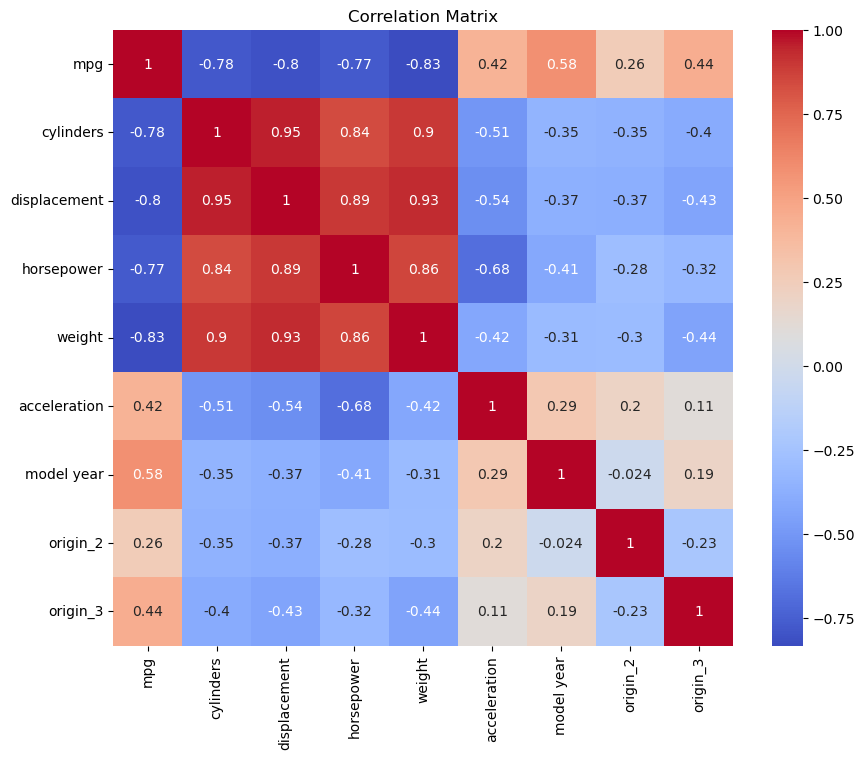

mpg             1.000000
model year      0.579267
origin_3        0.442174
acceleration    0.420289
origin_2        0.259022
horsepower     -0.771437
cylinders      -0.775396
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64

In [10]:
# Import new library
import matplotlib.pyplot as plt
import seaborn as sns

# Create correlation coeficient matrix
corr = new_auto_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Identify strongest correlations with mpg
corr["mpg"].sort_values(ascending=False)

##### Are there features highly correlated with mpg?

Yes, if we were to examine the heatmap for correlation, the following features would have a high correlation: weight, cylinders, displacement, & horsepower. It's a negative correlation, which means that these items contribute to having lower MPG than the other items. Which have a moderate correlation at best, typically resulting in better MPG.

##### Plot mpg versus weight. Analyze this graph and explain how it relates to the corresponding correlation coefficient.

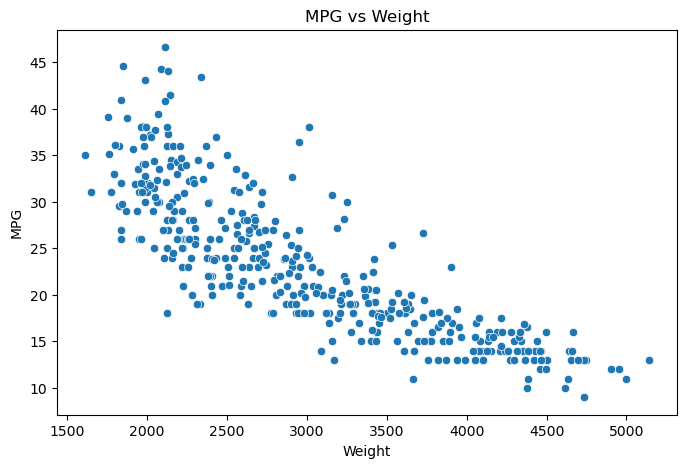

In [11]:
# Plot MPG vs Weight
plt.figure(figsize=(8, 5))
sns.scatterplot(x=new_auto_df["weight"], y=new_auto_df["mpg"])
plt.title("MPG vs Weight")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.show()

##### Analyze results



##### Randomly split the data into 80% training data and 20% test data, where your target is mpg.

In [12]:
# Import new library
from sklearn.model_selection import train_test_split

# Assign the 80/20 split to training & test data respectively
X = new_auto_df.drop(columns=["mpg"])
y = new_auto_df["mpg"]

# Calculate the results
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [13]:
# Check 80%
X_train.shape, X_test.shape

((318, 8), (80, 8))

In [14]:
# Check 20%
y_train.shape, y_test.shape

((318,), (80,))

In [15]:
# View train results
train_preview = pd.concat([X_train, y_train], axis=1)
train_preview.head()

,cylinders,displacement,horsepower,weight,acceleration,model year,origin_2,origin_3,mpg
3,8,304.0,150.0,3433,12.0,70,False,False,16.0
18,4,97.0,88.0,2130,14.5,70,False,True,27.0
376,4,91.0,68.0,2025,18.2,82,False,True,37.0
248,4,91.0,60.0,1800,16.4,78,False,True,36.1
177,4,115.0,95.0,2694,15.0,75,True,False,23.0


In [16]:
# View test results
test_preview = pd.concat([X_test, y_test], axis=1)
test_preview.head()

,cylinders,displacement,horsepower,weight,acceleration,model year,origin_2,origin_3,mpg
198,4,91.0,53.0,1795,17.4,76,False,True,33.0
396,4,120.0,79.0,2625,18.6,82,False,False,28.0
33,6,232.0,100.0,2634,13.0,71,False,False,19.0
208,8,318.0,150.0,3940,13.2,76,False,False,13.0
93,8,318.0,150.0,4237,14.5,73,False,False,14.0


##### Train an ordinary linear regression on the training data.

In [17]:
# Import new library
from sklearn.linear_model import LinearRegression

# Create linear regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

##### Calculate R2, RMSE, and MAE on both the training and test sets and interpret your results.

In [18]:
# Import new library
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Calculate R2, RMSE, & MAE
def evaluate(model, X_train, y_train, X_test, y_test):
    preds_train = model.predict(X_train)
    preds_test = model.predict(X_test)

    results = {
        "R2_train": r2_score(y_train, preds_train),
        "R2_test": r2_score(y_test, preds_test),
        "RMSE_train": np.sqrt(mean_squared_error(y_train, preds_train)),
        "RMSE_test": np.sqrt(mean_squared_error(y_test, preds_test)),
        "MAE_train": mean_absolute_error(y_train, preds_train),
        "MAE_test": mean_absolute_error(y_test, preds_test),
    }
    return results

    # Evaluate results
evaluate(lr, X_train, y_train, X_test, y_test)

{'R2_train': 0.8188288951042786,
 'R2_test': 0.8449006123776616,
 'RMSE_train': 3.3702735639389054,
 'RMSE_test': 2.887757347883632,
 'MAE_train': 2.605484693771036,
 'MAE_test': 2.2875867704421067}

#### Pick another regression model and repeat the previous two steps.

##### Utilizing the Ridge Regression model.

In [19]:
# Import Library
from sklearn.linear_model import Ridge

# Create the model
ridge = Ridge(alpha=1.0, random_state=42)

# Fit on training data
ridge.fit(X_train, y_train)

Ridge(random_state=42)

In [20]:
evaluate(ridge, X_train, y_train, X_test, y_test)

{'R2_train': 0.8187911937448994,
 'R2_test': 0.8447729434475323,
 'RMSE_train': 3.3706242194288163,
 'RMSE_test': 2.888945621607704,
 'MAE_train': 2.60471847802291,
 'MAE_test': 2.2915829296832464}